**Reading and Understanding the Data**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df=pd.read_csv("/content/advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


**Data Inspection**

In [ ]:
df.shape

(200, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


**Data Cleaning**

In [ ]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


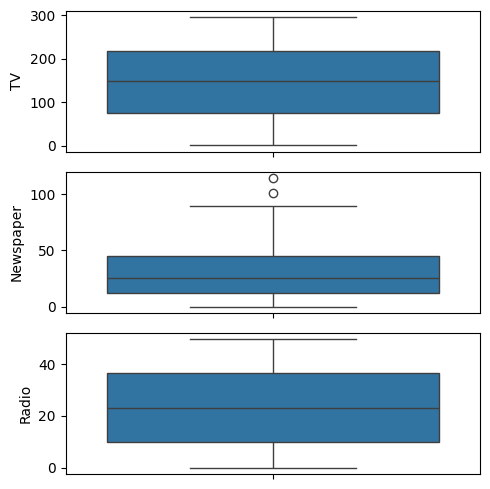

In [ ]:
fig, axs = plt.subplots(3, figsize = (5,5))
plt1 = sns.boxplot(df['TV'], ax = axs[0])
plt2 = sns.boxplot(df['Newspaper'], ax = axs[1])
plt3 = sns.boxplot(df['Radio'], ax = axs[2])
plt.tight_layout()

**Exploratory Data Analysis**

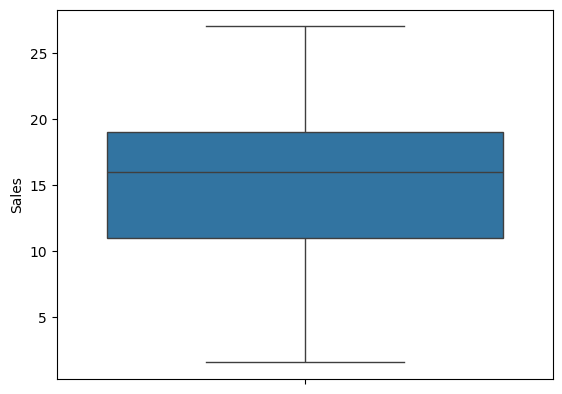

In [ ]:
sns.boxplot(df['Sales'])
plt.show()

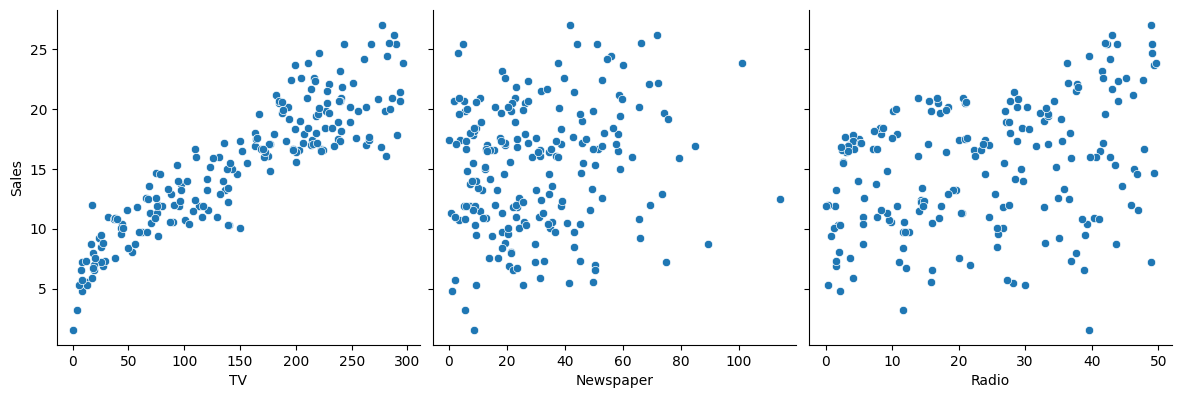

In [ ]:
sns.pairplot(df, x_vars=['TV', 'Newspaper', 'Radio'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.show()

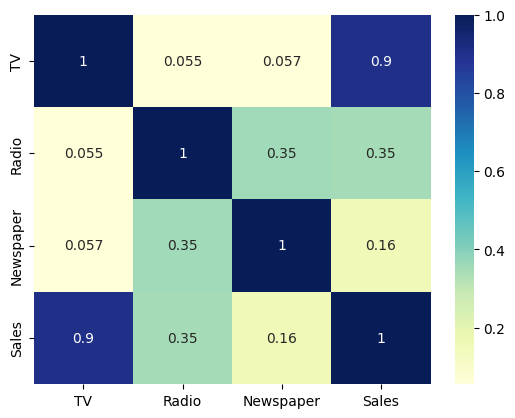

In [ ]:
sns.heatmap(df.corr(), cmap="YlGnBu", annot = True)
plt.show()

In [ ]:
X = df['TV']
y = df['Sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [ ]:
X_train.head()

,TV
79,116.0
197,177.0
38,43.1
24,62.3
122,224.0


In [ ]:
y_train.head()

,Sales
79,11.0
197,14.8
38,10.1
24,9.7
122,16.6


In [ ]:
lr = LinearRegression()
lr.fit(X_train.to_frame(), y_train)

y_pred_lr = lr.predict(X_test.to_frame())

In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\nLinear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)



Linear Regression Results
MAE : 1.9502948931650088
RMSE: 2.470035001123256
R2 Score: 0.802561303423698


In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train.to_frame(), y_train)

y_pred_rf = rf.predict(X_test.to_frame())

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)


Random Forest Results
MAE : 1.7696983333333332
RMSE: 2.2706143932009044
R2 Score: 0.8331551393765558


In [ ]:
if r2_rf > r2_lr:
    best_model = rf
    predictions = y_pred_rf
    model_name = "Random Forest"
else:
    best_model = lr
    predictions = y_pred_lr
    model_name = "Linear Regression"

print("\nBest Model:", model_name)



Best Model: Random Forest


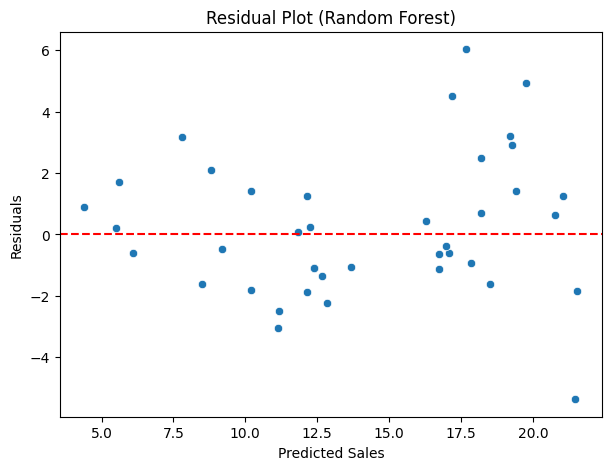

In [ ]:
residuals = y_test - predictions

plt.figure(figsize=(7,5))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title(f"Residual Plot ({model_name})")
plt.show()

In [ ]:
print("\nAdvertising Channel Impact")

if model_name == "Linear Regression":

    coefficients = pd.DataFrame({
        "Feature": [X.name],
        "Coefficient": lr.coef_
    })

    coefficients = coefficients.sort_values(
        by="Coefficient",
        ascending=False
    )

    print(coefficients)

    print("\nHighest Impact Channel:",
          coefficients.iloc[0]["Feature"])

else:

    importance = pd.DataFrame({
        "Feature": [X.name],
        "Importance": rf.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print(importance)

    print("\nHighest Impact Channel:",
          importance.iloc[0]["Feature"])



Advertising Channel Impact
  Feature  Importance
0      TV         1.0

Highest Impact Channel: TV
